In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Evaluación y Selección
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [9]:
# Definimos la ruta de tu archivo local
CSV_PATH = "outputs/processed/sevilla_pixel_data.csv"

# Cargamos el DataFrame
df = pd.read_csv(CSV_PATH)

print(f"✅ Dataset cargado correctamente: {CSV_PATH}")
print(f"Total de píxeles (registros): {len(df)}")
print(f"Variables disponibles: {list(df.columns)}")

# Mostramos las primeras filas para verificar
df.head()

✅ Dataset cargado correctamente: outputs/processed/sevilla_pixel_data.csv
Total de píxeles (registros): 484356
Variables disponibles: ['Longitude', 'Latitude', 'NDVI', 'NDBI', 'Albedo', 'D2W_meters', 'LST_Target', 'D2R_meters', 'Tree_Density_50m']


,Longitude,Latitude,NDVI,NDBI,Albedo,D2W_meters,LST_Target,D2R_meters,Tree_Density_50m
0,-6.029941,37.449956,0.505166,-0.178238,0.157998,20.000000,40.960874,2743.999249,1
1,-6.029762,37.449956,0.728687,-0.395285,0.181745,20.000000,40.714777,2743.879563,1
2,-6.029582,37.449956,0.763079,-0.424442,0.149877,20.000000,40.714777,2743.851804,1
3,-6.029402,37.449956,0.775685,-0.418584,0.147389,22.360680,40.379811,2729.205220,1
4,-6.029223,37.449956,0.835151,-0.530323,0.201774,28.284271,40.379811,2713.338171,1


In [11]:
# 1. Definimos cuáles son las variables predictoras (Features)
# Excluimos Lat y Lon para que el modelo aprenda de física y urbanismo, no de coordenadas
features = [
    'NDVI', 
    'NDBI', 
    'Albedo',
    'D2W_meters', 
    'D2R_meters',
    'Tree_Density_50m'
]

target = 'LST_Target'

# Eliminamos cualquier posible valor nulo que se haya colado en el CSV
df_clean = df.dropna(subset=features + [target]).copy()

X = df_clean[features] 
y = df_clean[target]

# 2. Partición 80% Entrenamiento / 20% Test oculto
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Escalamos los datos (Crucial para modelos lineales y redes neuronales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Tamaño de Entrenamiento: {X_train.shape}")
print(f"Tamaño de Test: {X_test.shape}")

Tamaño de Entrenamiento: (387484, 6)
Tamaño de Test: (96872, 6)


In [12]:
# Definimos los 4 modelos competidores
modelos = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
}

resultados = []

print("Evaluando modelos con Cross-Validation (5 particiones)...")
for nombre, modelo in modelos.items():
    # Usamos R2 y RMSE como métricas
    cv_scores_r2 = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_scores_mse = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-cv_scores_mse)
    
    resultados.append({
        "Modelo": nombre,
        "R2 Promedio": cv_scores_r2.mean(),
        "RMSE Promedio (°C)": rmse_scores.mean()
    })

df_resultados = pd.DataFrame(resultados).sort_values(by="R2 Promedio", ascending=False)
display(df_resultados)

Evaluando modelos con Cross-Validation (5 particiones)...


,Modelo,R2 Promedio,RMSE Promedio (°C)
1,Random Forest,0.676460,2.279755
2,XGBoost,0.629653,2.439096
3,LightGBM,0.605899,2.516099
0,Ridge Regression,0.380573,3.154422


In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# El ganador de la Fase 1: Random Forest
print("🌳 Iniciando Grid Search para Random Forest (Versión Segura y Ligera)...")

# Definimos el modelo base (n_jobs=-1 usa todos los núcleos de tu Mac)
modelo_ganador = RandomForestRegressor(random_state=42, n_jobs=-1)

# Cuadrícula de hiperparámetros blindada contra archivos gigantes
param_grid = {
    'n_estimators': [100, 200, 300],         # Rebajado el máximo: 300 es un bosque lo bastante robusto
    'max_depth': [15, 20, 25],               # ¡Adiós al None! Le ponemos un límite físico de altura
    'min_samples_split': [10, 20, 50],       # Exigimos agrupar al menos 10-50 píxeles para bifurcar
    'min_samples_leaf': [10, 20],            # CRÍTICO: La hoja final debe tener al menos 10-20 píxeles
    'max_features': ['sqrt', 'log2']         # Quitamos el 1.0 para ahorrar horas de computación
}

# Configuración del optimizador
grid_search = GridSearchCV(
    estimator=modelo_ganador,
    param_grid=param_grid,
    cv=3,                                   # 3-Fold CV
    scoring='r2',
    n_jobs=-1,                              
    verbose=2                               
)

# ¡A entrenar! (Esta vez será mucho más rápido)
grid_search.fit(X_train_scaled, y_train)

print(f"\n🏆 Mejores hiperparámetros encontrados: {grid_search.best_params_}")
mejor_modelo_final_RandomForest = grid_search.best_estimator_

🌳 Iniciando Grid Search para Random Forest (Versión Segura y Ligera)...
Fitting 3 folds for each of 108 candidates, totalling 324 fits


Python(26710) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26711) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26715) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26716) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26717) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26718) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26719) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26720) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26721) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26722) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26723) Malloc

[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=20, n_estimators=100; total time=  52.8s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=10, n_estimators=100; total time=  52.8s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=20, n_estimators=100; total time=  53.3s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=10, n_estimators=100; total time=  53.4s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=10, n_estimators=100; total time=  53.5s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=10, n_estimators=200; total time= 1.8min
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=10, n_estimators=200; total time= 1.8min
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=10, n_estimators=200; total time= 1.8min
[CV] END max_depth=15, m

Python(31302) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31308) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=20, min_samples_split=10, n_estimators=100; total time=  59.7s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=10, min_samples_split=50, n_estimators=200; total time= 1.9min
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=10, min_samples_split=50, n_estimators=200; total time= 1.9min
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=10, min_samples_split=50, n_estimators=200; total time= 1.9min
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=20, min_samples_split=10, n_estimators=100; total time=  56.2s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=20, min_samples_split=20, n_estimators=100; total time= 1.0min
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=10, min_samples_split=50, n_estimators=300; total time= 2.9min
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=10, min_samples_split=50, n_estimators=300; total time= 2.9min
[CV] END max_depth=25, m

Python(32462) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CV] END max_depth=25, max_features=log2, min_samples_leaf=10, min_samples_split=20, n_estimators=300; total time= 3.1min


Python(32486) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CV] END max_depth=25, max_features=log2, min_samples_leaf=20, min_samples_split=10, n_estimators=100; total time=  59.3s
[CV] END max_depth=25, max_features=log2, min_samples_leaf=10, min_samples_split=50, n_estimators=200; total time= 2.0min
[CV] END max_depth=25, max_features=log2, min_samples_leaf=10, min_samples_split=50, n_estimators=200; total time= 1.9min
[CV] END max_depth=25, max_features=log2, min_samples_leaf=10, min_samples_split=50, n_estimators=200; total time= 2.0min
[CV] END max_depth=25, max_features=log2, min_samples_leaf=20, min_samples_split=10, n_estimators=100; total time=  57.0s
[CV] END max_depth=25, max_features=log2, min_samples_leaf=20, min_samples_split=20, n_estimators=100; total time=  59.8s
[CV] END max_depth=25, max_features=log2, min_samples_leaf=10, min_samples_split=50, n_estimators=300; total time= 2.9min
[CV] END max_depth=25, max_features=log2, min_samples_leaf=10, min_samples_split=50, n_estimators=300; total time= 2.9min
[CV] END max_depth=25, m

--- MÉTRICAS FINALES EN TEST ---
R2 Score: 0.6622
RMSE: 2.3177 °C
MAE: 1.7178 °C


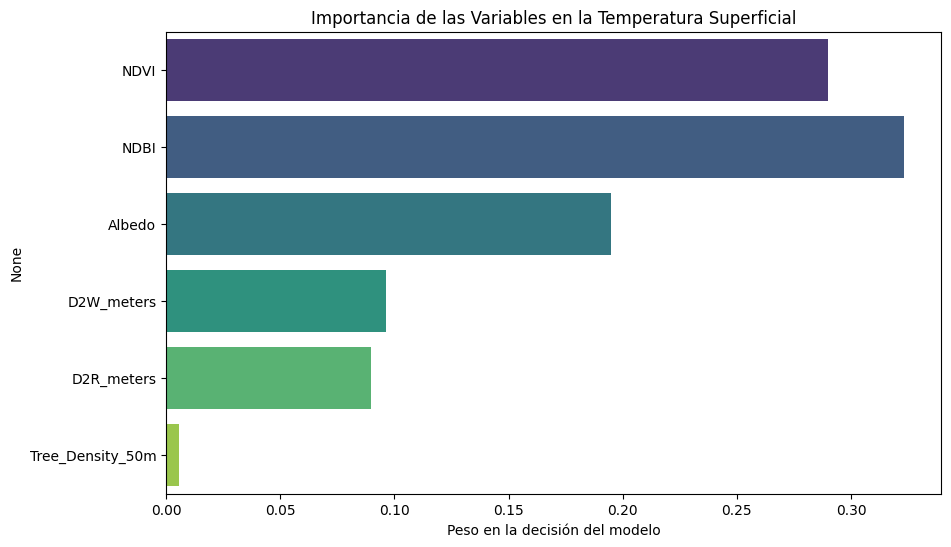

In [19]:
# Hacemos las predicciones sobre el 20% de datos que el modelo nunca ha visto
y_pred = mejor_modelo_final_RandomForest.predict(X_test_scaled)

print("--- MÉTRICAS FINALES EN TEST ---")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} °C")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f} °C")

# Gráfico de Importancia de Variables (Vital para el TFM)
importancias = mejor_modelo_final_RandomForest.feature_importances_
nombres_variables = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias, y=nombres_variables, palette="viridis")
plt.title("Importancia de las Variables en la Temperatura Superficial")
plt.xlabel("Peso en la decisión del modelo")
plt.show()

In [20]:
import joblib
import os

# Creamos una carpeta para guardar los modelos si no existe
os.makedirs("models", exist_ok=True)

# Ruta donde guardaremos el modelo ganador
ruta_modelo = "models/rf_sevilla_temperatura_v1.pkl"

# Guardamos el modelo
joblib.dump(mejor_modelo_final_RandomForest, ruta_modelo)

print(f"✅ ¡Modelo guardado de forma segura en {ruta_modelo}!")

✅ ¡Modelo guardado de forma segura en models/rf_sevilla_temperatura_v1.pkl!


In [21]:
# Suponiendo que el ganador es LightGBM (suele serlo en estos casos) o XGBoost
print("Iniciando Grid Search para el modelo ganador...")

modelo_ganador = XGBRegressor(random_state=42, verbose=-1)

# Definimos una cuadrícula de hiperparámetros a explorar
param_grid = {
    'n_estimators': [100, 300, 500],        # Cantidad de árboles
    'learning_rate': [0.01, 0.05, 0.1],     # Velocidad de aprendizaje
    'max_depth': [5, 10, -1],               # Profundidad del árbol (-1 es sin límite)
    'num_leaves': [31, 63, 127]             # Complejidad de las hojas
}

grid_search = GridSearchCV(
    estimator=modelo_ganador,
    param_grid=param_grid,
    cv=3,                                   # 3-Fold CV para no eternizar el proceso
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nMejores hiperparámetros encontrados: {grid_search.best_params_}")
mejor_modelo_final_XGBoost = grid_search.best_estimator_

Iniciando Grid Search para el modelo ganador...
Fitting 3 folds for each of 81 candidates, totalling 243 fits


Python(33826) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(33827) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(33828) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(33829) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



Mejores hiperparámetros encontrados: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 500, 'num_leaves': 31}


--- MÉTRICAS FINALES EN TEST ---
R2 Score: 0.6709
RMSE: 2.2876 °C
MAE: 1.6774 °C


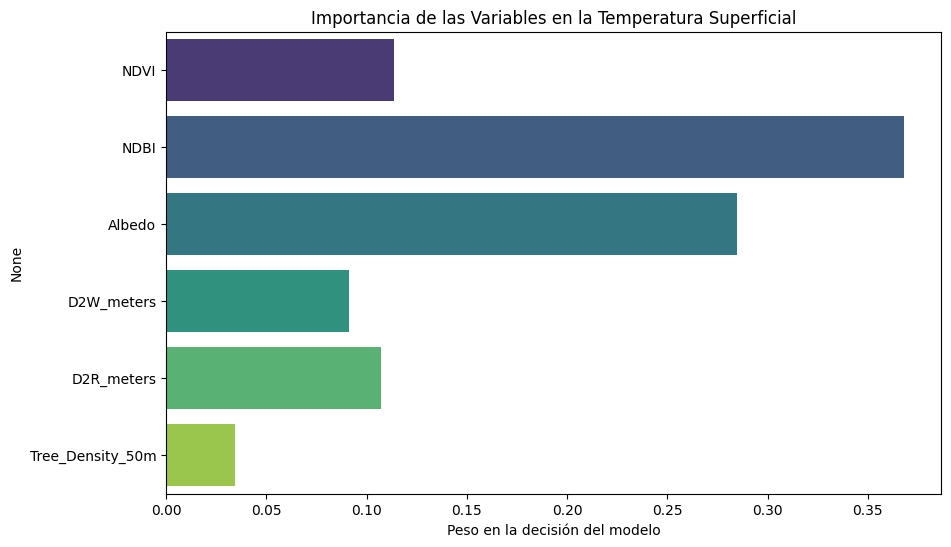

In [22]:
# Hacemos las predicciones sobre el 20% de datos que el modelo nunca ha visto
y_pred = mejor_modelo_final_XGBoost.predict(X_test_scaled)

print("--- MÉTRICAS FINALES EN TEST ---")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} °C")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f} °C")

# Gráfico de Importancia de Variables (Vital para el TFM)
importancias = mejor_modelo_final_XGBoost.feature_importances_
nombres_variables = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias, y=nombres_variables, palette="viridis")
plt.title("Importancia de las Variables en la Temperatura Superficial")
plt.xlabel("Peso en la decisión del modelo")
plt.show()

In [23]:
import joblib
import os

# Creamos una carpeta para guardar los modelos si no existe
os.makedirs("models", exist_ok=True)

# Ruta donde guardaremos el modelo ganador
ruta_modelo = "models/xgboost_sevilla_temperatura_v1.pkl"

# Guardamos el modelo
joblib.dump(mejor_modelo_final_XGBoost, ruta_modelo)

print(f"✅ ¡Modelo guardado de forma segura en {ruta_modelo}!")

✅ ¡Modelo guardado de forma segura en models/xgboost_sevilla_temperatura_v1.pkl!


In [24]:
import time

# Medir XGBoost
inicio = time.time()
xgb_preds = mejor_modelo_final_XGBoost.predict(X_test_scaled)
fin = time.time()
print(f"XGBoost tardó: {fin - inicio:.4f} segundos")

# Medir Random Forest
inicio = time.time()
rf_preds = mejor_modelo_final_RandomForest.predict(X_test_scaled)
fin = time.time()
print(f"Random Forest tardó: {fin - inicio:.4f} segundos")

XGBoost tardó: 0.1154 segundos
Random Forest tardó: 0.7358 segundos


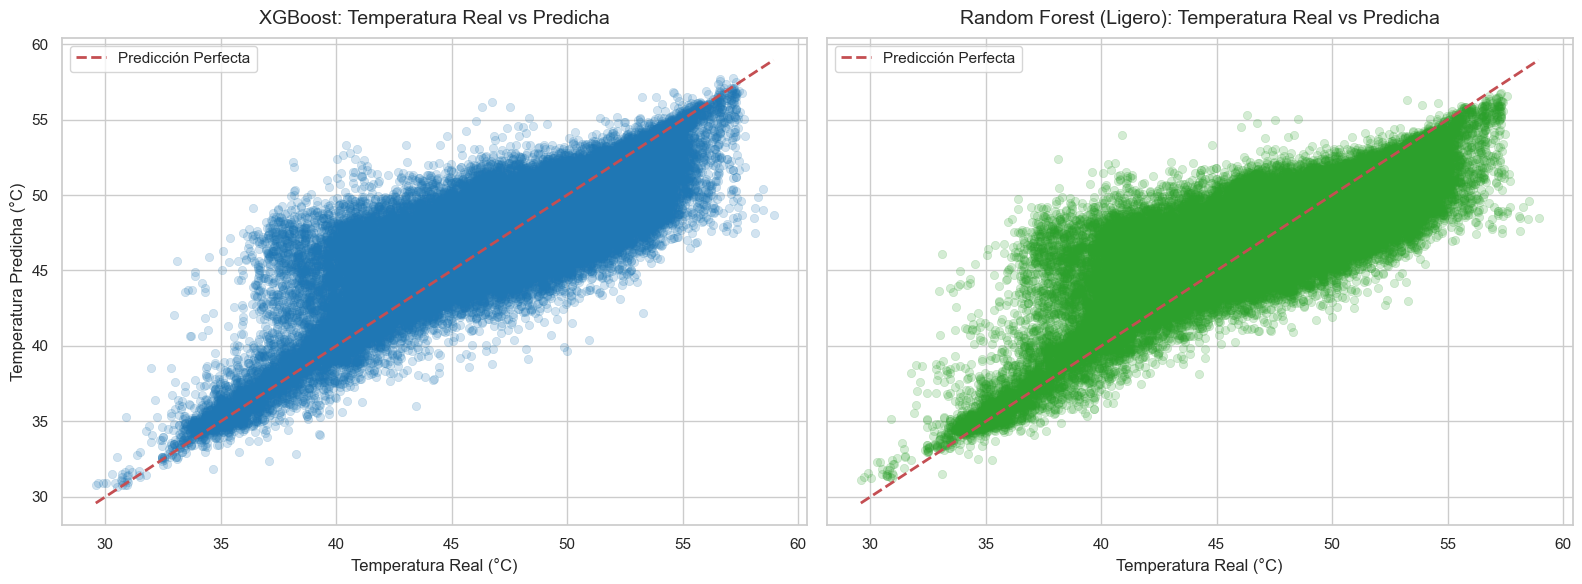

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar el estilo del gráfico
sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Límite para la línea de predicción perfecta (y = x)
min_val = min(y_test.min(), xgb_preds.min(), rf_preds.min())
max_val = max(y_test.max(), xgb_preds.max(), rf_preds.max())

# --- Panel 1: XGBoost ---
sns.scatterplot(x=y_test, y=xgb_preds, ax=axes[0], alpha=0.2, color="#1f77b4", edgecolor=None)
# Añadir la línea ideal en rojo
axes[0].plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label="Predicción Perfecta")
axes[0].set_title('XGBoost: Temperatura Real vs Predicha', fontsize=14, pad=10)
axes[0].set_xlabel('Temperatura Real (°C)', fontsize=12)
axes[0].set_ylabel('Temperatura Predicha (°C)', fontsize=12)
axes[0].legend()

# --- Panel 2: Random Forest ---
sns.scatterplot(x=y_test, y=rf_preds, ax=axes[1], alpha=0.2, color="#2ca02c", edgecolor=None)
# Añadir la línea ideal en rojo
axes[1].plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label="Predicción Perfecta")
axes[1].set_title('Random Forest (Ligero): Temperatura Real vs Predicha', fontsize=14, pad=10)
axes[1].set_xlabel('Temperatura Real (°C)', fontsize=12)
axes[1].legend()

# Ajustar el layout y mostrar
plt.tight_layout()
plt.show()